### C-V Characteristics of Solar cell


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable

### For Ambient Light

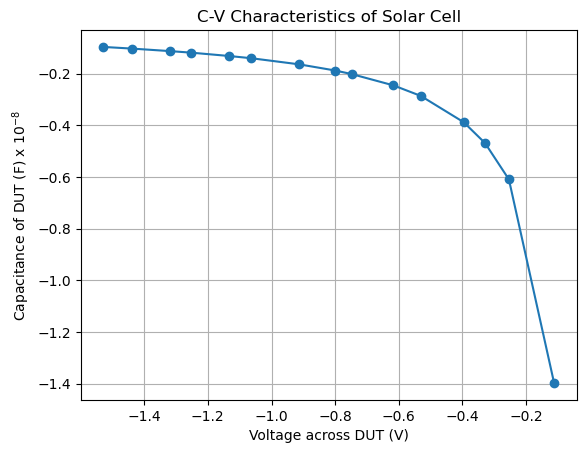

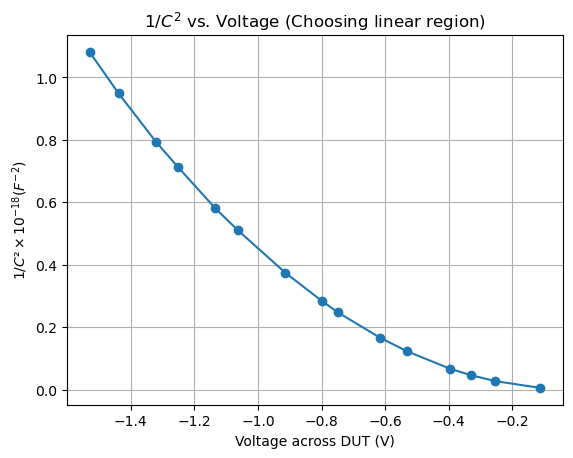

In [63]:
#SI Units
C_f = 5e-9 
Rf = 10e3 
w = 2 * np.pi * 5000
term = np.sqrt(1+ 1/(w**2 * Rf**2 * C_f**2))

V_DUT = np.array([-0.112,-0.254,-0.329,-0.396,-0.531,-0.617,-0.748,-0.800,-0.914,-1.064,-1.134,-1.252,-1.320,-1.438,-1.529])
V_out = np.array([0.264,0.261,0.260,0.259,0.256,0.255,0.254,0.253,0.252,0.251,0.251,0.250,0.250,0.249,0.248])
C_DUT = C_f * term* (V_out/V_DUT)

plt.plot(V_DUT, C_DUT*1e8, marker='o', linestyle='-')
plt.xlabel('Voltage across DUT (V)')
plt.ylabel(r"Capacitance of DUT (F) x $10^{-8}$")
plt.title('C-V Characteristics of Solar Cell')
plt.grid()
plt.show()

C_invsq = 1/C_DUT**2
C_invsq = C_invsq * 1e-18 # Scale for better readability
plt.plot(V_DUT, C_invsq, marker='o', linestyle='-')
plt.xlabel('Voltage across DUT (V)')
plt.ylabel(r'$1/C² \times 10^{-18} (F^{-2})$')
plt.title(r"$1/C^2$ vs. Voltage (Choosing linear region)")
plt.grid()
plt.show()


+--------------------------------------+
|              Input Data              |
+---+--------+-------+--------+--------+
| i |   x    |   y   |   x²   |   xy   |
+---+--------+-------+--------+--------+
| 1 | -1.064 | 0.511 | 1.132  | -0.544 |
| 2 | -1.134 | 0.581 | 1.286  | -0.659 |
| 3 | -1.252 | 0.714 | 1.568  | -0.894 |
| 4 | -1.32  | 0.794 | 1.742  | -1.047 |
| 5 | -1.438 | 0.949 | 2.068  | -1.365 |
| 6 | -1.529 | 1.082 | 2.338  | -1.654 |
| Σ | -7.737 | 4.631 | 10.134 | -6.164 |
+---+--------+-------+--------+--------+ 

+----------------------------------------+
|    Fit Results & Statistical Errors    |
+------------------+-------+-------------+
|    Parameter     | Value | Uncertainty |
+------------------+-------+-------------+
|    Slope (a₁)    | -1.22 |    ±0.04    |
|  Intercept (a₀)  | -0.81 |    ±0.05    |
| σ_y (Std. Error) |  0.02 |             |
|    Δ (delta)     |  0.94 |             |
+------------------+-------+-------------+ 

+--------------------------------

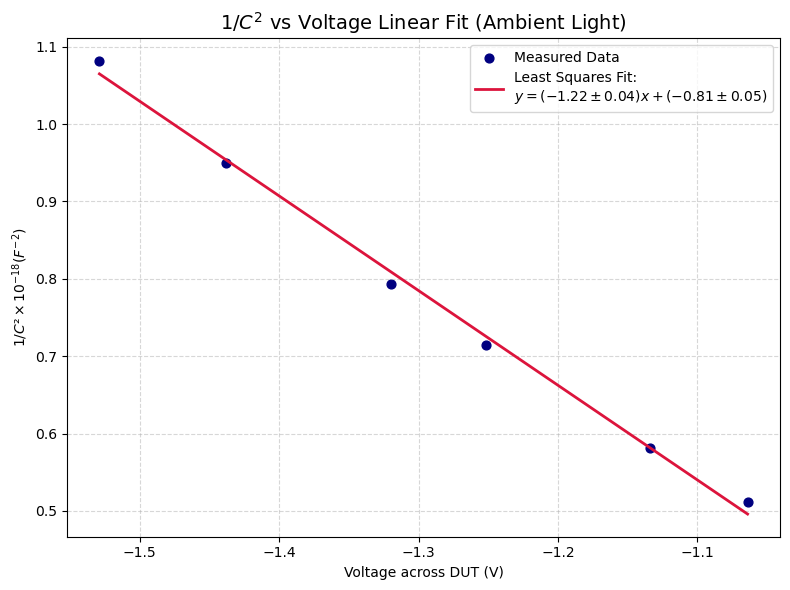

In [64]:
x = V_DUT[9:]
y = C_invsq[9:]  # Scale for better readability
n = len(x)

# --- Data Table ---
table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 3), round(y[i], 3), round(x[i]**2, 3), round(x[i]*y[i], 3)])
table_data.add_row(["Σ", round(np.sum(x), 3), round(np.sum(y), 3), round(np.sum(x**2), 3), round(np.sum(x*y), 3)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.2f}", f"±{sigma_a1:.2f}"])
results.add_row(["Intercept (a₀)", f"{a0:.2f}", f"±{sigma_a0:.2f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.2f}", ""])
results.add_row(["Δ (delta)", f"{delta:.2f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 3), round(yi, 3), round(yfi, 3)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.2f} \pm {sigma_a1:.2f})x + ({a0:.2f} \pm {sigma_a0:.2f})$')
plt.xlabel('Voltage across DUT (V)')
plt.ylabel(r'$1/C² \times 10^{-18} (F^{-2})$')
plt.title(r"$1/C^2$ vs Voltage Linear Fit (Ambient Light)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Data for Dark room

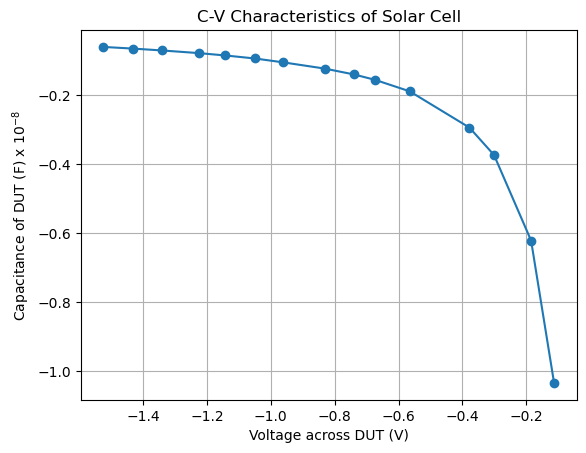

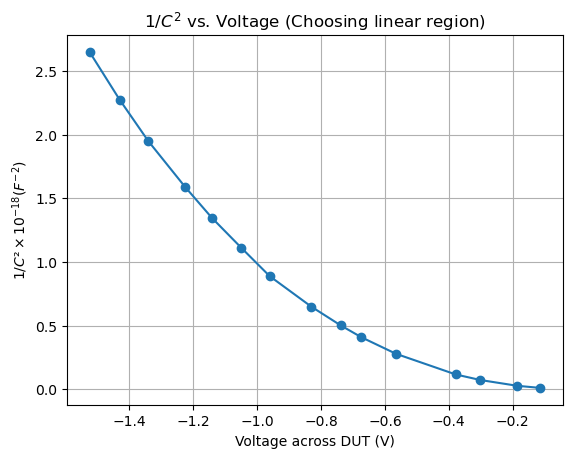

In [65]:
V_DUT = np.array([-0.113,-0.185,-0.301,-0.378,-0.565,-0.674,-0.739,-0.831,-0.961,-1.050,-1.142,-1.226,-1.341,-1.431,-1.525])
V_out = np.array([0.197,0.194,0.190,0.188,0.181,0.178,0.176,0.174,0.172,0.168,0.166,0.164,0.162,0.160,0.158])
C_DUT = C_f * term* (V_out/V_DUT)

plt.plot(V_DUT, C_DUT*1e8, marker='o', linestyle='-')
plt.xlabel('Voltage across DUT (V)')
plt.ylabel(r"Capacitance of DUT (F) x $10^{-8}$")
plt.title('C-V Characteristics of Solar Cell')
plt.grid()
plt.show()

C_invsq = 1/C_DUT**2
C_invsq = C_invsq * 1e-18 # Scale for better readability
plt.plot(V_DUT, C_invsq, marker='o', linestyle='-')
plt.xlabel('Voltage across DUT (V)')
plt.ylabel(r'$1/C² \times 10^{-18} (F^{-2})$')
plt.title(r"$1/C^2$ vs. Voltage (Choosing linear region)")
plt.grid()
plt.show()


+----------------------------------------+
|               Input Data               |
+---+--------+--------+--------+---------+
| i |   x    |   y    |   x²   |    xy   |
+---+--------+--------+--------+---------+
| 1 | -0.961 | 0.889  | 0.924  |  -0.854 |
| 2 | -1.05  | 1.112  | 1.102  |  -1.167 |
| 3 | -1.142 | 1.347  | 1.304  |  -1.538 |
| 4 | -1.226 | 1.591  | 1.503  |  -1.95  |
| 5 | -1.341 |  1.95  | 1.798  |  -2.615 |
| 6 | -1.431 | 2.277  | 2.048  |  -3.258 |
| 7 | -1.525 | 2.652  | 2.326  |  -4.044 |
| Σ | -8.676 | 11.817 | 11.005 | -15.427 |
+---+--------+--------+--------+---------+ 

+----------------------------------------+
|    Fit Results & Statistical Errors    |
+------------------+-------+-------------+
|    Parameter     | Value | Uncertainty |
+------------------+-------+-------------+
|    Slope (a₁)    | -3.10 |    ±0.12    |
|  Intercept (a₀)  | -2.16 |    ±0.15    |
| σ_y (Std. Error) |  0.06 |             |
|    Δ (delta)     |  1.76 |             |
+--------

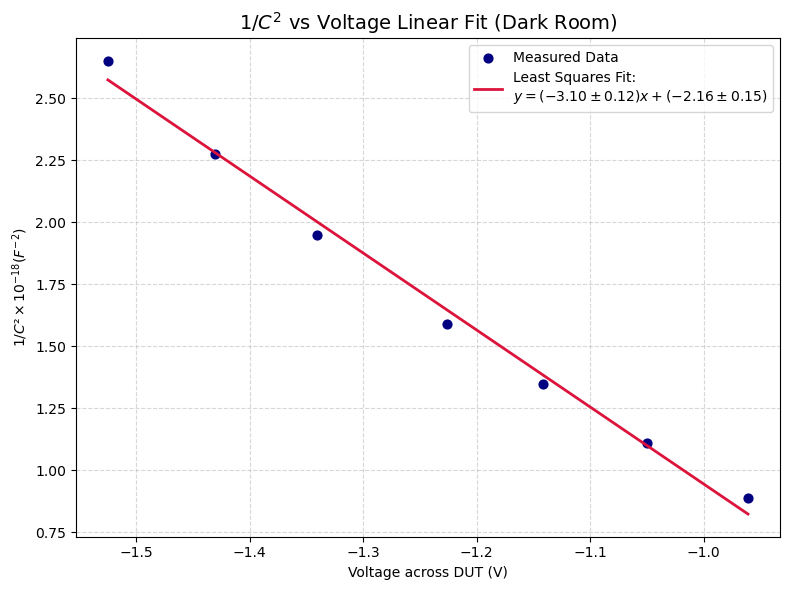

In [66]:
x = V_DUT[8:]
y = C_invsq[8:]  # Scale for better readability
n = len(x)

# --- Data Table ---
table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 3), round(y[i], 3), round(x[i]**2, 3), round(x[i]*y[i], 3)])
table_data.add_row(["Σ", round(np.sum(x), 3), round(np.sum(y), 3), round(np.sum(x**2), 3), round(np.sum(x*y), 3)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.2f}", f"±{sigma_a1:.2f}"])
results.add_row(["Intercept (a₀)", f"{a0:.2f}", f"±{sigma_a0:.2f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.2f}", ""])
results.add_row(["Δ (delta)", f"{delta:.2f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 3), round(yi, 3), round(yfi, 3)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.2f} \pm {sigma_a1:.2f})x + ({a0:.2f} \pm {sigma_a0:.2f})$')
plt.xlabel('Voltage across DUT (V)')
plt.ylabel(r'$1/C² \times 10^{-18} (F^{-2})$')
plt.title(r"$1/C^2$ vs Voltage Linear Fit (Dark Room)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()